In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#to get rid of scientific notation
pd.options.display.float_format = '{:.2f}'.format

HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')

display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


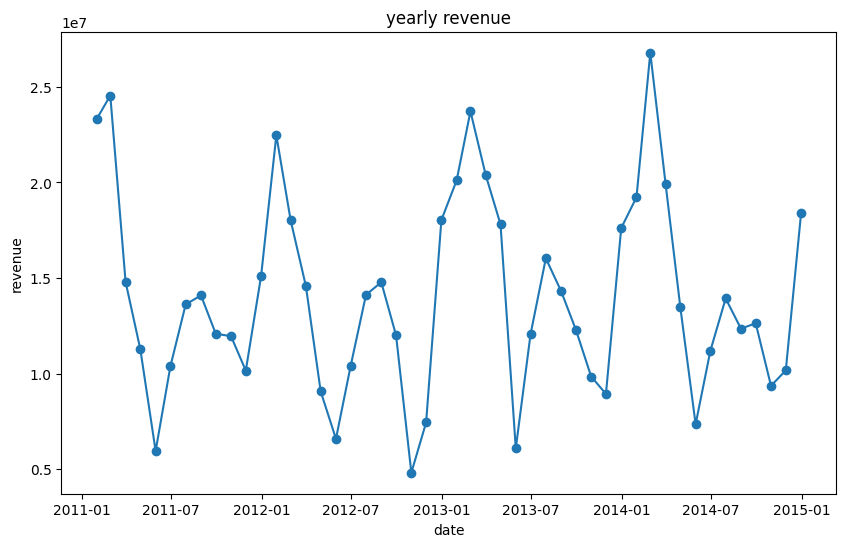

In [ ]:
#FIRST convert your date into a date type
HS_data['date'] = pd.to_datetime(HS_data['date'])

# identify the patterns in the data and how the datapoints are correlated
# by first visualizing the data, then finding numeric correlations in the data

# establish the canvas using plt.figure()
# create our labels using plt.title, plt.xlabel, and plt.ylabel

# plot our data using plt.plot(data points on our x axis, data points on our y axis, any visual stuff for our graph)
plt.figure(figsize=(10,6))

plt.title('yearly revenue')

plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(HS_data['date'], HS_data['revenue'], marker='o')

In [ ]:
# how to see numeric or quantitative relationships we use the .corr()
HS_data.loc[:,['revenue','production','coolDD','heatDD']].corr()

,revenue,production,coolDD,heatDD
revenue,1.00,0.63,-0.17,0.69
production,0.63,1.00,0.51,0.03
coolDD,-0.17,0.51,1.00,-0.72
heatDD,0.69,0.03,-0.72,1.00


In [ ]:
# separate our data into its training and testing set
dt4training = HS_data.loc[HS_data['type']=='dt4training']
dt4testing = HS_data.loc[HS_data['type']=='dt4testing']

dt4testing

,type,date,revenue,production,coolDD,heatDD
36,dt4testing,2014-01-31,19228840,606400,0,1123
37,dt4testing,2014-02-28,26792280,714128,0,938
38,dt4testing,2014-03-31,19935840,805600,0,866
39,dt4testing,2014-04-30,13468000,375856,0,412
40,dt4testing,2014-05-31,7344128,279296,49,88
41,dt4testing,2014-06-30,11196216,517600,230,0
42,dt4testing,2014-07-31,13929472,749472,380,0
43,dt4testing,2014-08-31,12352176,663432,322,0
44,dt4testing,2014-09-30,12628944,701656,178,14
45,dt4testing,2014-10-31,9361000,411728,24,166


In [ ]:
#to actually train the model we need to do the following
# make sure library is imported
# scikitlearn - used much more in data/scomputer scienc
# we will use statsmodels - used much more in acct and finance
import statsmodels.api as sm

# prepare the dependent and independent variables for our mdoelling

#dependent variable
y = dt4training.loc[:,'revenue']

#independent variable prep
x = dt4training.loc[:,'production']

# add the constant aka the "b"
x = sm.add_constant(x)

#now python will go and do a bunch of math to figure out what the m and b values should actually be

#now we make a new model, named model 1 by using sm.OLD(y,x).fit()
model1 = sm.OLS(y,x).fit()

model1.params

,0
const,4897663.26
production,18.99


# revenue = 18.99 * production + 4897663.26
#y = mx + b

In [ ]:
# in order to test the model we do the following:
# prepare the testing version of our independent variable
# WE DO NOT mess with our testing version of the dependent variable (in this case revenue)

# preparing the testing independent variable

x_test = dt4testing.loc[:,'production']

# next add your constant

x_test = sm.add_constant(x_test)

#finally we can use our model (named model1) to forecast future values, remember that we call it future values
# but we actually have them after the training dataset
# our model was trained on the training data so it doesnt know about the testing data

display(model1.predict(x_test))
display(HS_data)

,0
36,16414428.69
37,18460401.82
38,20197640.55
39,12035930.72
40,10202060.55
41,14727936.65
42,19131656.04
43,17497582.00
44,18223533.25
45,12717212.73


,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


In [ ]:
#final step is to compare the predicted numbers vs actual numbers from the testing data
# MAPE score
# Mean Absolute Percentage Error

# first copy your TESTING data to a new dataframe to compare because we never want to mess with our
# original training or testing data

model1_assessment = dt4testing.copy()

#next add a column with our predicted revenue numbers so we can see them alongside actuals
model1_assessment['model1_predicted_revenue'] = model1.predict(x_test)

#find the percentage error at each row, then find the mean of that
model1_assessment['percentage_error'] = abs((model1_assessment['revenue'] - model1_assessment['model1_predicted_revenue']
                                             )/ model1_assessment['revenue'])

display(model1_assessment)

,type,date,revenue,production,coolDD,heatDD,model1_predicted_revenue,percentage_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,16414428.69,0.15
37,dt4testing,2014-02-28,26792280,714128,0,938,18460401.82,0.31
38,dt4testing,2014-03-31,19935840,805600,0,866,20197640.55,0.01
39,dt4testing,2014-04-30,13468000,375856,0,412,12035930.72,0.11
40,dt4testing,2014-05-31,7344128,279296,49,88,10202060.55,0.39
41,dt4testing,2014-06-30,11196216,517600,230,0,14727936.65,0.32
42,dt4testing,2014-07-31,13929472,749472,380,0,19131656.04,0.37
43,dt4testing,2014-08-31,12352176,663432,322,0,17497582.00,0.42
44,dt4testing,2014-09-30,12628944,701656,178,14,18223533.25,0.44
45,dt4testing,2014-10-31,9361000,411728,24,166,12717212.73,0.36


In [ ]:
model1_assessment['percentage_error'].mean()

np.float64(0.2542315606071484)

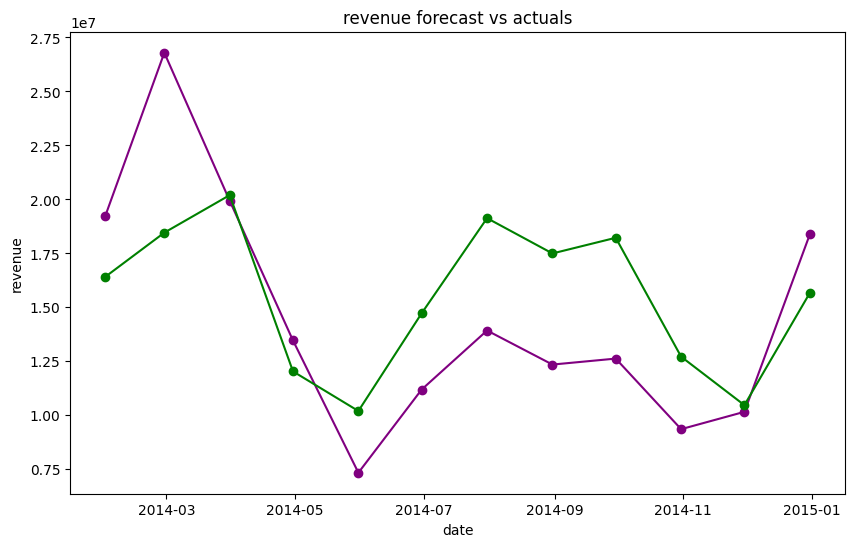

In [ ]:
#finally visualize actual vs predicted to see results visually

plt.figure(figsize=(10,6))

plt.title('revenue forecast vs actuals')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model1_assessment['date'],model1_assessment['revenue'],marker='o', color='purple')
plt.plot(model1_assessment['date'],model1_assessment['model1_predicted_revenue'],marker ='o', color='green')

In [ ]:
# Multiple regression: Production + CoolDD
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:, ['production','coolDD']]

x = sm.add_constant(x)

mrmodel1 = sm.OLS(y, x).fit()

mrmodel1.params

,0
const,1544742.70
production,31.98
coolDD,-23477.27


In [ ]:
x_test = dt4testing.loc[:,['production','coolDD']]
x_test = sm.add_constant(x_test)

mrmodel1_assessment = dt4testing.copy()

mrmodel1_assessment['mrmodel1_predicted_revenue'] = mrmodel1.predict(x_test)

mrmodel1_assessment['mrmodel1_abs_pct_error'] = abs((mrmodel1_assessment['revenue'] - mrmodel1_assessment['mrmodel1_predicted_revenue'])/mrmodel1_assessment['revenue'])

display(mrmodel1_assessment)
mrmodel1_assessment['mrmodel1_abs_pct_error'].mean()

,type,date,revenue,production,coolDD,heatDD,mrmodel1_predicted_revenue,mrmodel1_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,20938961.80,0.09
37,dt4testing,2014-02-28,26792280,714128,0,938,24384378.09,0.09
38,dt4testing,2014-03-31,19935840,805600,0,866,27309886.02,0.37
39,dt4testing,2014-04-30,13468000,375856,0,412,13565576.50,0.01
40,dt4testing,2014-05-31,7344128,279296,49,88,9326955.28,0.27
41,dt4testing,2014-06-30,11196216,517600,230,0,12699139.92,0.13
42,dt4testing,2014-07-31,13929472,749472,380,0,16593408.05,0.19
43,dt4testing,2014-08-31,12352176,663432,322,0,15203310.81,0.23
44,dt4testing,2014-09-30,12628944,701656,178,14,19806538.25,0.57
45,dt4testing,2014-10-31,9361000,411728,24,166,14149400.18,0.51


np.float64(0.21738596854659376)

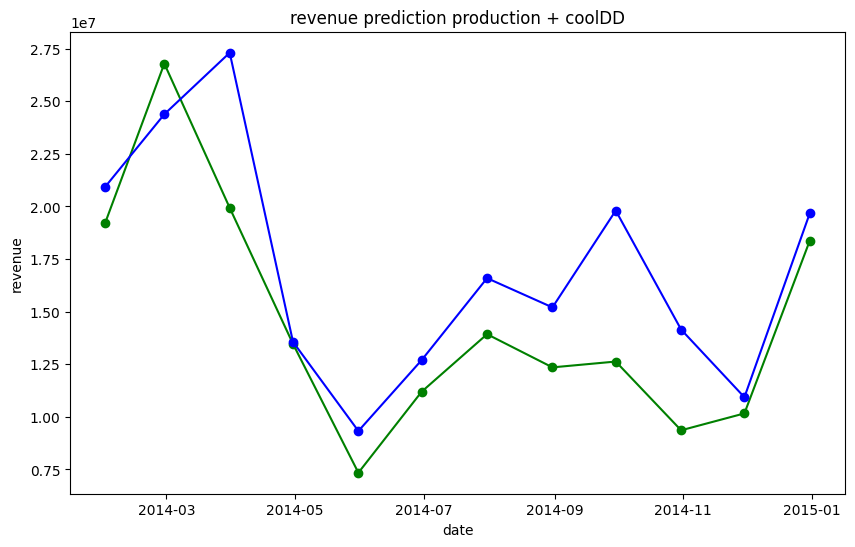

In [ ]:
plt.figure(figsize=(10,6))

plt.title('revenue prediction production + coolDD')
plt.ylabel('revenue')
plt.xlabel('date')

plt.plot(mrmodel1_assessment['date'],mrmodel1_assessment['revenue'],marker='o',color='green')
plt.plot(mrmodel1_assessment['date'],mrmodel1_assessment['mrmodel1_predicted_revenue'],marker='o',color='blue')

revenue = 1544742.7 + 31.98 * production -23477.27 * coolDD

## Week 10: Multiple Regression
Extending the univariate model above to multiple regression, then the participation exercise: univariate models on Production, CoolDD, and HeatDD, multiple regression combinations, and finding the best model by MAPE.

In [ ]:
# Univariate model: Production only
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:, ['production']]

x = sm.add_constant(x)

mrmodel2 = sm.OLS(y, x).fit()

mrmodel2.params

,0
const,4897663.26
production,18.99


In [ ]:
x_test = dt4testing.loc[:,['production']]
x_test = sm.add_constant(x_test)

mrmodel2_assessment = dt4testing.copy()

mrmodel2_assessment['mrmodel2_predicted_revenue'] = mrmodel2.predict(x_test)

mrmodel2_assessment['mrmodel2_abs_pct_error'] = abs((mrmodel2_assessment['revenue'] - mrmodel2_assessment['mrmodel2_predicted_revenue'])/mrmodel2_assessment['revenue'])

display(mrmodel2_assessment)
mrmodel2_assessment['mrmodel2_abs_pct_error'].mean()

,type,date,revenue,production,coolDD,heatDD,mrmodel2_predicted_revenue,mrmodel2_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,16414428.69,0.15
37,dt4testing,2014-02-28,26792280,714128,0,938,18460401.82,0.31
38,dt4testing,2014-03-31,19935840,805600,0,866,20197640.55,0.01
39,dt4testing,2014-04-30,13468000,375856,0,412,12035930.72,0.11
40,dt4testing,2014-05-31,7344128,279296,49,88,10202060.55,0.39
41,dt4testing,2014-06-30,11196216,517600,230,0,14727936.65,0.32
42,dt4testing,2014-07-31,13929472,749472,380,0,19131656.04,0.37
43,dt4testing,2014-08-31,12352176,663432,322,0,17497582.00,0.42
44,dt4testing,2014-09-30,12628944,701656,178,14,18223533.25,0.44
45,dt4testing,2014-10-31,9361000,411728,24,166,12717212.73,0.36


np.float64(0.2542315606071484)

In [ ]:
# Univariate model: CoolDD only
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:, ['coolDD']]

x = sm.add_constant(x)

mrmodel3 = sm.OLS(y, x).fit()

mrmodel3.params

,0
const,14341632.04
coolDD,-4113.94


In [ ]:
x_test = dt4testing.loc[:,['coolDD']]
x_test = sm.add_constant(x_test)

mrmodel3_assessment = dt4testing.copy()

mrmodel3_assessment['mrmodel3_predicted_revenue'] = mrmodel3.predict(x_test)

mrmodel3_assessment['mrmodel3_abs_pct_error'] = abs((mrmodel3_assessment['revenue'] - mrmodel3_assessment['mrmodel3_predicted_revenue'])/mrmodel3_assessment['revenue'])

display(mrmodel3_assessment)
mrmodel3_assessment['mrmodel3_abs_pct_error'].mean()

,type,date,revenue,production,coolDD,heatDD,mrmodel3_predicted_revenue,mrmodel3_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,14341632.04,0.25
37,dt4testing,2014-02-28,26792280,714128,0,938,14341632.04,0.46
38,dt4testing,2014-03-31,19935840,805600,0,866,14341632.04,0.28
39,dt4testing,2014-04-30,13468000,375856,0,412,14341632.04,0.06
40,dt4testing,2014-05-31,7344128,279296,49,88,14140049.20,0.93
41,dt4testing,2014-06-30,11196216,517600,230,0,13395426.88,0.20
42,dt4testing,2014-07-31,13929472,749472,380,0,12778336.56,0.08
43,dt4testing,2014-08-31,12352176,663432,322,0,13016944.82,0.05
44,dt4testing,2014-09-30,12628944,701656,178,14,13609351.53,0.08
45,dt4testing,2014-10-31,9361000,411728,24,166,14242897.59,0.52


np.float64(0.2960295810593141)

In [ ]:
# Univariate model: HeatDD only
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:, ['heatDD']]

x = sm.add_constant(x)

mrmodel4 = sm.OLS(y, x).fit()

mrmodel4.params

,0
const,10333861.28
heatDD,9991.26


In [ ]:
x_test = dt4testing.loc[:,['heatDD']]
x_test = sm.add_constant(x_test)

mrmodel4_assessment = dt4testing.copy()

mrmodel4_assessment['mrmodel4_predicted_revenue'] = mrmodel4.predict(x_test)

mrmodel4_assessment['mrmodel4_abs_pct_error'] = abs((mrmodel4_assessment['revenue'] - mrmodel4_assessment['mrmodel4_predicted_revenue'])/mrmodel4_assessment['revenue'])

display(mrmodel4_assessment)
mrmodel4_assessment['mrmodel4_abs_pct_error'].mean()

,type,date,revenue,production,coolDD,heatDD,mrmodel4_predicted_revenue,mrmodel4_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,21554043.42,0.12
37,dt4testing,2014-02-28,26792280,714128,0,938,19705660.79,0.26
38,dt4testing,2014-03-31,19935840,805600,0,866,18986290.25,0.05
39,dt4testing,2014-04-30,13468000,375856,0,412,14450259.35,0.07
40,dt4testing,2014-05-31,7344128,279296,49,88,11213091.93,0.53
41,dt4testing,2014-06-30,11196216,517600,230,0,10333861.28,0.08
42,dt4testing,2014-07-31,13929472,749472,380,0,10333861.28,0.26
43,dt4testing,2014-08-31,12352176,663432,322,0,10333861.28,0.16
44,dt4testing,2014-09-30,12628944,701656,178,14,10473738.88,0.17
45,dt4testing,2014-10-31,9361000,411728,24,166,11992410.02,0.28


np.float64(0.21648503280089135)

In [ ]:
# Multiple regression: Production + HeatDD
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:, ['production','heatDD']]

x = sm.add_constant(x)

mrmodel5 = sm.OLS(y, x).fit()

mrmodel5.params

,0
const,727257.88
production,20.00
heatDD,10484.05


In [ ]:
x_test = dt4testing.loc[:,['production','heatDD']]
x_test = sm.add_constant(x_test)

mrmodel5_assessment = dt4testing.copy()

mrmodel5_assessment['mrmodel5_predicted_revenue'] = mrmodel5.predict(x_test)

mrmodel5_assessment['mrmodel5_abs_pct_error'] = abs((mrmodel5_assessment['revenue'] - mrmodel5_assessment['mrmodel5_predicted_revenue'])/mrmodel5_assessment['revenue'])

display(mrmodel5_assessment)
mrmodel5_assessment['mrmodel5_abs_pct_error'].mean()

,type,date,revenue,production,coolDD,heatDD,mrmodel5_predicted_revenue,mrmodel5_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,24628392.67,0.28
37,dt4testing,2014-02-28,26792280,714128,0,938,24843321.50,0.07
38,dt4testing,2014-03-31,19935840,805600,0,866,25917840.64,0.30
39,dt4testing,2014-04-30,13468000,375856,0,412,12563524.46,0.07
40,dt4testing,2014-05-31,7344128,279296,49,88,7235563.93,0.01
41,dt4testing,2014-06-30,11196216,517600,230,0,11078867.46,0.01
42,dt4testing,2014-07-31,13929472,749472,380,0,15716132.56,0.13
43,dt4testing,2014-08-31,12352176,663432,322,0,13995397.46,0.13
44,dt4testing,2014-09-30,12628944,701656,178,14,14906625.37,0.18
45,dt4testing,2014-10-31,9361000,411728,24,166,10701860.21,0.14


np.float64(0.13857863869363204)

In [ ]:
# Multiple regression: CoolDD + HeatDD
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:, ['coolDD','heatDD']]

x = sm.add_constant(x)

mrmodel6 = sm.OLS(y, x).fit()

mrmodel6.params

,0
const,4808087.92
coolDD,22847.06
heatDD,18008.95


In [ ]:
x_test = dt4testing.loc[:,['coolDD','heatDD']]
x_test = sm.add_constant(x_test)

mrmodel6_assessment = dt4testing.copy()

mrmodel6_assessment['mrmodel6_predicted_revenue'] = mrmodel6.predict(x_test)

mrmodel6_assessment['mrmodel6_abs_pct_error'] = abs((mrmodel6_assessment['revenue'] - mrmodel6_assessment['mrmodel6_predicted_revenue'])/mrmodel6_assessment['revenue'])

display(mrmodel6_assessment)
mrmodel6_assessment['mrmodel6_abs_pct_error'].mean()

,type,date,revenue,production,coolDD,heatDD,mrmodel6_predicted_revenue,mrmodel6_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,25032135.65,0.30
37,dt4testing,2014-02-28,26792280,714128,0,938,21700480.42,0.19
38,dt4testing,2014-03-31,19935840,805600,0,866,20403836.22,0.02
39,dt4testing,2014-04-30,13468000,375856,0,412,12227774.18,0.09
40,dt4testing,2014-05-31,7344128,279296,49,88,7512381.01,0.02
41,dt4testing,2014-06-30,11196216,517600,230,0,10062910.76,0.10
42,dt4testing,2014-07-31,13929472,749472,380,0,13489969.14,0.03
43,dt4testing,2014-08-31,12352176,663432,322,0,12164839.90,0.02
44,dt4testing,2014-09-30,12628944,701656,178,14,9126989.12,0.28
45,dt4testing,2014-10-31,9361000,411728,24,166,8345902.50,0.11


np.float64(0.13869856580272627)

In [ ]:
# Multiple regression: Production + CoolDD + HeatDD
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:, ['production','coolDD','heatDD']]

x = sm.add_constant(x)

mrmodel7 = sm.OLS(y, x).fit()

mrmodel7.params

,0
const,702694.56
production,21.54
coolDD,-2950.07
heatDD,9486.65


In [ ]:
x_test = dt4testing.loc[:,['production','coolDD','heatDD']]
x_test = sm.add_constant(x_test)

mrmodel7_assessment = dt4testing.copy()

mrmodel7_assessment['mrmodel7_predicted_revenue'] = mrmodel7.predict(x_test)

mrmodel7_assessment['mrmodel7_abs_pct_error'] = abs((mrmodel7_assessment['revenue'] - mrmodel7_assessment['mrmodel7_predicted_revenue'])/mrmodel7_assessment['revenue'])

display(mrmodel7_assessment)
mrmodel7_assessment['mrmodel7_abs_pct_error'].mean()

,type,date,revenue,production,coolDD,heatDD,mrmodel7_predicted_revenue,mrmodel7_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,24415491.93,0.27
37,dt4testing,2014-02-28,26792280,714128,0,938,24980466.18,0.07
38,dt4testing,2014-03-31,19935840,805600,0,866,26267346.70,0.32
39,dt4testing,2014-04-30,13468000,375856,0,412,12705541.31,0.06
40,dt4testing,2014-05-31,7344128,279296,49,88,7407819.55,0.01
41,dt4testing,2014-06-30,11196216,517600,230,0,11171091.17,0.00
42,dt4testing,2014-07-31,13929472,749472,380,0,15722122.14,0.13
43,dt4testing,2014-08-31,12352176,663432,322,0,14040288.76,0.14
44,dt4testing,2014-09-30,12628944,701656,178,14,15421094.34,0.22
45,dt4testing,2014-10-31,9361000,411728,24,166,11073554.36,0.18


np.float64(0.1428584482208116)

In [ ]:
# Compare all models by MAPE
model_names = ['mrmodel1: Production+CoolDD', 'mrmodel2: Production only', 'mrmodel3: CoolDD only', 'mrmodel4: HeatDD only', 'mrmodel5: Production+HeatDD', 'mrmodel6: CoolDD+HeatDD', 'mrmodel7: Production+CoolDD+HeatDD']
mape_values = [mrmodel1_assessment['mrmodel1_abs_pct_error'].mean(), mrmodel2_assessment['mrmodel2_abs_pct_error'].mean(), mrmodel3_assessment['mrmodel3_abs_pct_error'].mean(), mrmodel4_assessment['mrmodel4_abs_pct_error'].mean(), mrmodel5_assessment['mrmodel5_abs_pct_error'].mean(), mrmodel6_assessment['mrmodel6_abs_pct_error'].mean(), mrmodel7_assessment['mrmodel7_abs_pct_error'].mean()]

mape_summary = pd.DataFrame({'model': model_names, 'mape': mape_values})
mape_summary = mape_summary.sort_values('mape')
mape_summary

,model,mape
4,mrmodel5: Production+HeatDD,0.14
5,mrmodel6: CoolDD+HeatDD,0.14
6,mrmodel7: Production+CoolDD+HeatDD,0.14
3,mrmodel4: HeatDD only,0.22
0,mrmodel1: Production+CoolDD,0.22
1,mrmodel2: Production only,0.25
2,mrmodel3: CoolDD only,0.30


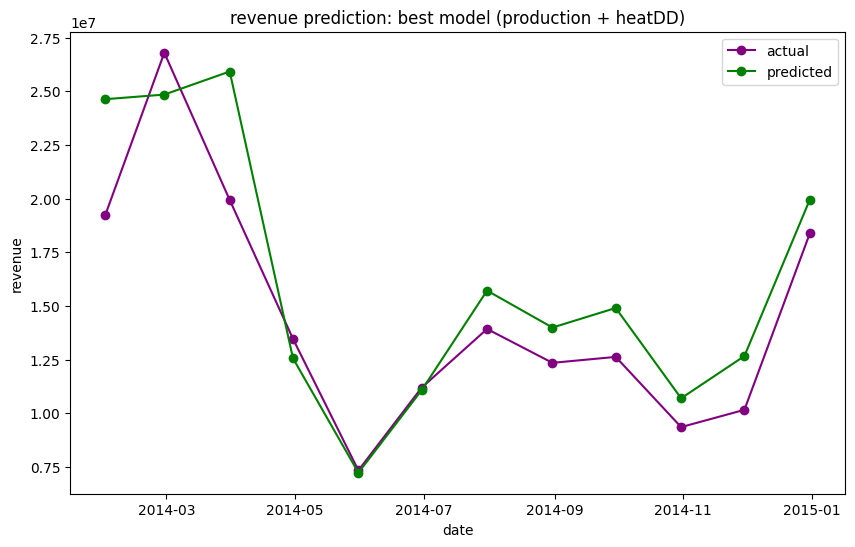

In [ ]:
# Best model: mrmodel5 (Production + HeatDD)
plt.figure(figsize=(10,6))

plt.title('revenue prediction: best model (production + heatDD)')
plt.ylabel('revenue')
plt.xlabel('date')

plt.plot(mrmodel5_assessment['date'],mrmodel5_assessment['revenue'],marker='o',color='purple',label='actual')
plt.plot(mrmodel5_assessment['date'],mrmodel5_assessment['mrmodel5_predicted_revenue'],marker='o',color='green',label='predicted')
plt.legend()

## Conclusion

Across the seven models tested, the univariate models each captured only one driver of revenue: Production alone gave a MAPE of 0.25, CoolDD alone gave 0.30, and HeatDD alone gave 0.22, with HeatDD being the strongest single predictor. Combining variables improved accuracy substantially. Production + CoolDD (mrmodel1) reached 0.22, matching HeatDD alone but not beating it. The best-performing model was mrmodel5, Production + HeatDD, with a MAPE of 0.139. CoolDD + HeatDD (mrmodel6, MAPE 0.139) and the full three-variable model (mrmodel7, MAPE 0.143) performed almost identically to mrmodel5 but did not improve on it, suggesting CoolDD and Production largely explain overlapping variation once HeatDD is included. Overall, HeatDD is the single most powerful predictor of revenue, and pairing it with Production gives the best forecast accuracy without added model complexity, so mrmodel5 (Production + HeatDD) is the recommended model.